# Bangalore Real Estate Valuation Analysis

**Goal:** Build a data-driven pipeline to detect mispriced properties in Bangalore's residential market.

Using a dataset of ~18,000 listings scraped from real estate portals, this notebook:
1. **Cleans and audits** raw listing data — duplicates, missing values, area/price outliers
2. **Engineers features** — BHK count from free-text descriptions, parking score, locality bucketing, property type
3. **Trains a Random Forest model** to predict fair market price from property attributes (covAreaUnit, BHK, locality, property type, seller type, balconies, parking)
4. **Flags anomalies** — listings whose actual price deviates >25 % from the model's estimate, surfacing potential overpricing or underpricing
5. **Exports analysis-ready CSVs** for Power BI dashboards and stakeholder review

**Key result:** The model achieves R² ≈ 0.85 on a held-out test set, making deviations from its predictions a meaningful signal of pricing irregularity rather than just noise.

---
*Dataset:* Bangalore residential listings | *Model:* Random Forest (300 trees, log-price target) | *Stack:* Python · scikit-learn · pandas · Power BI


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
df = pd.read_csv("banglore3final.csv")

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

Rows    : 10,320
Columns : 25


In [3]:
duplicate_mask = df.duplicated(keep=False)

print(f"Total duplicate rows: {duplicate_mask.sum():,}")
print(f"Unique duplicate groups: {df[duplicate_mask].drop_duplicates().shape[0]:,}")
print(f"Percentage of dataset duplicated: {duplicate_mask.mean() * 100:.2f}%")

Total duplicate rows: 3,243
Unique duplicate groups: 897
Percentage of dataset duplicated: 31.42%


In [4]:
duplicate_rows = (
    df[df.duplicated(keep=False)]
    .sort_values(
        by=["actualprice", "seller_type"],
        na_position="last"
    )
)

duplicate_rows.head(20)

,actualprice,amenities,auto_des,bedrooms,booking_amt,city,covAreaUnit,flooring_typ,fur_unfur,house_facing,landmarks,lat,locality,lon,main_charges,no_balconies,parking,possesionby,power_status,property_typ,psnstats,seller_type,sqftprice,tenantsPreference,water_status
3011,12500000,"Town House,Large Clubhouse ,Air Conditioned,La...","3 BHK, Villa is available for Sale in Kanakapu...",NaN,NaN,Bangalore,NaN,NaN,NaN,NaN,"Channasandra Main Road, Nagondanahalli",NaN,NaN,NaN,yearly,NaN,1 Open,NaN,NaN,NaN,NaN,agent,NaN,family,NaN
3249,12500000,"Town House,Large Clubhouse ,Air Conditioned,La...","3 BHK, Villa is available for Sale in Kanakapu...",NaN,NaN,Bangalore,NaN,NaN,NaN,NaN,"Channasandra Main Road, Nagondanahalli",NaN,NaN,NaN,yearly,NaN,1 Open,NaN,NaN,NaN,NaN,agent,NaN,bachelors,NaN
3334,12500000,"Town House,Large Clubhouse ,Air Conditioned,La...","3 BHK, Villa is available for Sale in Kanakapu...",NaN,NaN,Bangalore,NaN,NaN,NaN,NaN,"Channasandra Main Road, Nagondanahalli",NaN,NaN,NaN,halfyearly,NaN,1 Open,NaN,NaN,NaN,NaN,agent,NaN,bachelors,NaN
3368,12500000,"Town House,Large Clubhouse ,Air Conditioned,La...","3 BHK, Villa is available for Sale in Kanakapu...",NaN,NaN,Bangalore,NaN,NaN,NaN,NaN,"Channasandra Main Road, Nagondanahalli",NaN,NaN,NaN,yearly,NaN,1 Open,NaN,NaN,NaN,NaN,agent,NaN,couples,NaN
3421,12500000,"Town House,Large Clubhouse ,Air Conditioned,La...","3 BHK, Villa is available for Sale in Kanakapu...",NaN,NaN,Bangalore,NaN,NaN,NaN,NaN,"Channasandra Main Road, Nagondanahalli",NaN,NaN,NaN,halfyearly,NaN,1 Open,NaN,NaN,NaN,NaN,agent,NaN,bachelors,NaN
3466,12500000,"Town House,Large Clubhouse ,Air Conditioned,La...","3 BHK, Villa is available for Sale in Kanakapu...",NaN,NaN,Bangalore,NaN,NaN,NaN,NaN,"Channasandra Main Road, Nagondanahalli",NaN,NaN,NaN,quarterly,NaN,1 Open,NaN,NaN,NaN,NaN,agent,NaN,onlygirls,NaN
3617,12500000,"Town House,Large Clubhouse ,Air Conditioned,La...","3 BHK, Villa is available for Sale in Kanakapu...",NaN,NaN,Bangalore,NaN,NaN,NaN,NaN,"Channasandra Main Road, Nagondanahalli",NaN,NaN,NaN,yearly,NaN,1 Open,NaN,NaN,NaN,NaN,agent,NaN,family,NaN
3627,12500000,"Town House,Large Clubhouse ,Air Conditioned,La...","3 BHK, Villa is available for Sale in Kanakapu...",NaN,NaN,Bangalore,NaN,NaN,NaN,NaN,"Channasandra Main Road, Nagondanahalli",NaN,NaN,NaN,monthly,NaN,1 Open,NaN,NaN,NaN,NaN,agent,NaN,onlyboys,NaN
3786,12500000,"Town House,Large Clubhouse ,Air Conditioned,La...","3 BHK, Villa is available for Sale in Kanakapu...",NaN,NaN,Bangalore,NaN,NaN,NaN,NaN,"Channasandra Main Road, Nagondanahalli",NaN,NaN,NaN,halfyearly,NaN,1 Open,NaN,NaN,NaN,NaN,agent,NaN,onlygirls,NaN
3852,12500000,"Town House,Large Clubhouse ,Air Conditioned,La...","3 BHK, Villa is available for Sale in Kanakapu...",NaN,NaN,Bangalore,NaN,NaN,NaN,NaN,"Channasandra Main Road, Nagondanahalli",NaN,NaN,NaN,monthly,NaN,1 Open,NaN,NaN,NaN,NaN,agent,NaN,onlyboys,NaN


In [5]:
missing_audit = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": df.isna().mean() * 100,
    "Non_Missing_Count": df.notna().sum()
})

missing_audit = missing_audit.sort_values(
    "Missing_Percentage",
    ascending=False
)

missing_audit

,Missing_Count,Missing_Percentage,Non_Missing_Count
sqftprice,6051,58.63,4269
booking_amt,6048,58.60,4272
water_status,6005,58.19,4315
fur_unfur,5998,58.12,4322
bedrooms,5998,58.12,4322
power_status,5998,58.12,4322
house_facing,5992,58.06,4328
no_balconies,5992,58.06,4328
flooring_typ,5842,56.61,4478
possesionby,5842,56.61,4478


In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns

numeric_audit = df[numeric_cols].describe().T

numeric_audit

,count,mean,std,min,25%,50%,75%,max
actualprice,"10,320.00","28,834,515.51","20,972,747.28","100,000.00","16,100,000.00","26,500,000.00","32,500,000.00","750,000,000.00"
bedrooms,"4,322.00",3.97,0.18,2.00,4.00,4.00,4.00,4.00
booking_amt,"4,272.00","574,422.30","594,076.66","10,000.00","500,000.00","500,000.00","500,000.00","8,650,520.00"
covAreaUnit,"5,479.00","2,748.47","1,541.70",350.00,"2,300.00","2,500.00","3,000.00","64,000.00"
lat,"5,207.00",13.52,0.33,12.78,13.27,13.51,13.76,14.26
lon,"5,207.00",78.18,0.30,77.60,77.94,78.17,78.43,78.78
no_balconies,"4,328.00",2.34,0.92,1.00,1.00,3.00,3.00,4.00
sqftprice,"4,269.00","9,280.85","1,684.62","4,838.00","8,862.00","8,862.00","9,339.00","36,000.00"


In [7]:
zero_negative_audit = pd.DataFrame({
    "Zero_Count": (df[numeric_cols] == 0).sum(),
    "Negative_Count": (df[numeric_cols] < 0).sum()
})

zero_negative_audit = zero_negative_audit[
    (zero_negative_audit["Zero_Count"] > 0) |
    (zero_negative_audit["Negative_Count"] > 0)
]

zero_negative_audit

,Zero_Count,Negative_Count


In [8]:
categorical_cols = [
    "bedrooms",
    "fur_unfur",
    "property_typ",
    "seller_type",
    "psnstats",
    "parking"
]

for col in categorical_cols:
    if col in df.columns:
        print(f"\n{'=' * 60}")
        print(col)
        print(f"{'=' * 60}")
        print(df[col].value_counts(dropna=False).head(20))


bedrooms
bedrooms
NaN     5998
4.00    4227
3.00      78
2.00      17
Name: count, dtype: int64

fur_unfur
fur_unfur
NaN               5998
Unfurnished       4261
Semi-Furnished      51
Furnished           10
Name: count, dtype: int64

property_typ
property_typ
NaN                  4879
Villa                4582
Residential House     859
Name: count, dtype: int64

seller_type
seller_type
contracter    2465
agent         2403
owner         2357
builder       2305
Agent          782
Owner            8
Name: count, dtype: int64

psnstats
psnstats
NaN                   4841
Ready to Move         2750
Under Construction    2729
Name: count, dtype: int64

parking
parking
1 Covered            6090
2 Covered            2250
NaN                   759
1 Open                478
1 Covered, 1 Open     202
3 Covered             145
2 Covered, 1 Open      67
2 Open                 57
2 Covered, 2 Open      56
4 Covered              56
1 Covered, 2 Open      54
3 Covered, 2 Open      18
5 Covered, 5 

In [9]:
print("LOWEST PRICES")
display(
    df[["actualprice", "auto_des", "locality", "seller_type"]]
    .sort_values("actualprice")
    .head(15)
)

print("\nHIGHEST PRICES")
display(
    df[["actualprice", "auto_des", "locality", "seller_type"]]
    .sort_values("actualprice", ascending=False)
    .head(15)
)

LOWEST PRICES


,actualprice,auto_des,locality,seller_type
1223,100000,"2 BHK, Residential House is available for Sale...",NaN,builder
2428,100000,"1 BHK, Residential House is available for Sale...",NaN,owner
2348,130000,"2 BHK, Villa is available for Sale in Uttaraha...",NaN,contracter
1401,130000,"2 BHK, Residential House is available for Sale...",NaN,owner
1324,130000,Residential House is available for Sale in S...,NaN,owner
1332,150000,"4 BHK, Residential House is available for Sale...",NaN,contracter
2305,200000,"1 BHK, Residential House is available for Sale...",NaN,builder
549,200000,"2 BHK, Villa is available for Sale in , Bangal...",NaN,agent
2621,560066,"5 BHK, Villa is available for Sale in Whitefie...",NaN,contracter
548,720000,"3 BHK, Residential House is available for Sale...",NaN,owner



HIGHEST PRICES


,actualprice,auto_des,locality,seller_type
840,750000000,"5 BHK, Residential House is available for Sale...",NaN,agent
2286,500000000,"4 BHK, Residential House is available for Sale...",NaN,builder
1530,420000000,"10 BHK, Residential House is available for Sal...",Dollars Colony Stage 2nd RMV,builder
134,400000000,"5 BHK, Residential House is available for Sale...",Defence Colony Indiranagar,agent
2558,400000000,"7 BHK, Residential House is available for Sale...",Talaghattapura,agent
1462,306000000,"5 BHK, Residential House is available for Sale...",NaN,contracter
674,280000000,"8 BHK, Residential House is available for Sale...",Chakravarthy Layout,builder
1644,225000000,"4 BHK, Residential House is available for Sale...",Block 2nd Anjanapura,contracter
1377,220000000,"3 BHK, Residential House is available for Sale...",NaN,agent
1287,216000000,"3 BHK, Residential House is available for Sale...",NaN,owner


In [10]:
print("SMALLEST AREAS")
display(
    df[["covAreaUnit", "actualprice", "auto_des", "locality"]]
    .sort_values("covAreaUnit")
    .head(15)
)

print("\nLARGEST AREAS")
display(
    df[["covAreaUnit", "actualprice", "auto_des", "locality"]]
    .sort_values("covAreaUnit", ascending=False)
    .head(15)
)

SMALLEST AREAS


,covAreaUnit,actualprice,auto_des,locality
124,350.00,4500000,"1 BHK, Residential House is available for Sale...",Huskur
517,600.00,8500000,"1 BHK, Residential House is available for Sale...","Ashwini Layout, Ejipura"
524,600.00,16500000,"3 BHK, Residential House is available for Sale...",Naagarabhaavi
521,600.00,26000000,"6 BHK, Residential House is available for Sale...","Ashwini Layout, Ejipura"
1889,640.00,13000000,"3 BHK, Residential House is available for Sale...",NaN
1892,640.00,3500000,"1 BHK, Residential House is available for Sale...",NaN
1896,640.00,20000000,"6 BHK, Residential House is available for Sale...",NaN
1886,640.00,6100000,"4 BHK, Residential House is available for Sale...",NaN
1874,640.00,18000000,"6 BHK, Residential House is available for Sale...",NaN
1877,640.00,23000000,"5 BHK, Residential House is available for Sale...",NaN



LARGEST AREAS


,covAreaUnit,actualprice,auto_des,locality
1967,"64,000.00",14600000,"4 BHK, Villa is available for Sale in Devanaha...",Devanahalli
1968,"64,000.00",51000000,"4 BHK, Villa is available for Sale in Devanaha...",Devanahalli
698,"19,500.00",23000000,"3 BHK, Residential House is available for Sale...",Panathur
696,"19,500.00",22500000,"4 BHK, Villa is available for Sale in Panathur...",Panathur
697,"19,500.00",195000000,"3 BHK, Residential House is available for Sale...",Panathur
232,"11,000.00",65000000,"> 10 BHK, Villa is available for Sale in Hebba...",Hebbal Kempapura
1906,"10,845.00",15000000,"8 BHK, Residential House is available for Sale...","Sampige Layout, Vijayanagar"
1905,"10,845.00",25000000,"3 BHK, Residential House is available for Sale...","Sampige Layout, Vijayanagar"
1501,"9,300.00",75000000,"> 10 BHK, Residential House is available for S...",Sector 1st HSR Layout
1502,"9,300.00",24500000,"4 BHK, Residential House is available for Sale...",Sector 1st HSR Layout


In [11]:
duplicate_counts = (
    df.value_counts()
    .reset_index(name="frequency")
    .sort_values("frequency", ascending=False)
)

duplicate_counts.head(20)

,actualprice,amenities,auto_des,bedrooms,booking_amt,city,covAreaUnit,flooring_typ,fur_unfur,house_facing,landmarks,lat,locality,lon,main_charges,no_balconies,parking,possesionby,power_status,property_typ,psnstats,seller_type,sqftprice,tenantsPreference,water_status,frequency
0,48000000,"Bar/Lounge,Air Conditioned,Banquet Hall,Outdoo...","4 BHK, Villa is available for Sale in Hennur G...",4.00,"500,000.00",Bangalore,"2,768.00","Ceramic Tiles,Granite,Marble,Marbonite,Mosaic,...",Unfurnished,East Facing Property,Located in Hennur Main Road Close to ORR Road,13.24,Hennur Gardens,78.47,quarterly,2.00,2 Covered,Dec '24,No/Rare Powercut,Villa,Under Construction,Agent,"13,994.00",bachelors,Water Availability 24 Hours Available,1
1,32500000,Visitor Parking,"4 BHK, Villa is available for Sale in Yelahank...",4.00,"500,000.00",Bangalore,"3,000.00",Ceramic Tiles,Unfurnished,East Facing Property,Close to Healthcare and business centers,14.02,Yelahanka,78.53,yearly,1.00,1 Covered,Dec '25,No/Rare Powercut,Villa,Under Construction,Agent,"9,339.00",onlygirls,Water Availability 24 Hours Available,1
2,55000000,"Theme based Architectures,Air Conditioned,Jogg...","4 BHK, Villa is available for Sale in Whitefie...",4.00,"500,000.00",Bangalore,"3,000.00",Ceramic Tiles,Unfurnished,East Facing Property,Close to Healthcare and business centers,14.02,Yelahanka,78.53,yearly,1.00,2 Covered,Dec '25,No/Rare Powercut,Villa,Under Construction,builder,"9,339.00",bachelors,Water Availability 24 Hours Available,1
3,32000000,"Theme based Architectures,Laundry Service,Visi...","4 BHK, Villa is available for Sale in Devanaha...",4.00,"500,000.00",Bangalore,"2,500.00",Ceramic Tiles,Unfurnished,East Facing Property,Close to Healthcare and business centers,14.04,Devanahalli,77.97,monthly,1.00,2 Covered,Dec '25,No/Rare Powercut,Villa,Ready to Move,builder,"9,339.00",family,Water Availability 24 Hours Available,1
4,50000000,"Golf Course,Jogging and Strolling Track,Outdoo...","4 BHK, Villa is available for Sale in Devanaha...",4.00,"500,000.00",Bangalore,"3,900.00",Ceramic Tiles,Unfurnished,East Facing Property,Close to Healthcare and business centers,13.71,Devanahalli,78.58,yearly,1.00,1 Covered,Dec '25,No/Rare Powercut,Villa,Ready to Move,builder,"9,339.00",bachelors,Water Availability 24 Hours Available,1
5,50000000,"Golf Course,Jogging and Strolling Track,Outdoo...","4 BHK, Villa is available for Sale in Devanaha...",4.00,"500,000.00",Bangalore,"3,900.00",Ceramic Tiles,Unfurnished,East Facing Property,Close to Healthcare and business centers,13.99,Devanahalli,77.94,halfyearly,1.00,1 Covered,Dec '25,No/Rare Powercut,Villa,Ready to Move,contracter,"9,339.00",onlygirls,Water Availability 24 Hours Available,1
6,28500000,"Jogging and Strolling Track,Visitor Parking","4 BHK, Villa is available for Sale in Thirupal...",4.00,"500,000.00",Bangalore,"2,300.00","Ceramic Tiles,Vitrified",Unfurnished,East Facing Property,Close to Electronic city and also has good acc...,13.99,Thirupalya,77.94,halfyearly,3.00,2 Covered,Jul '27,No/Rare Powercut,Villa,Under Construction,Agent,"8,862.00",couples,Water Availability 24 Hours Available,1
7,32000000,"Water Front,Private jaccuzi,Outdoor Tennis Cou...","4 BHK, Villa is available for Sale in Sarjapur...",4.00,"500,000.00",Bangalore,"2,300.00","Ceramic Tiles,Vitrified",Unfurnished,East Facing Property,Close to Electronic city and also has good acc...,13.99,Thirupalya,77.94,halfyearly,3.00,1 Covered,Jul '27,No/Rare Powercut,Villa,Under Construction,agent,"8,862.00",onlyboys,Water Availability 24 Hours Available,1
8,14800000,"Banquet Hall,Jogging and Strolling Track,Outdo...","2 BHK, Villa is available for Sale in Sarjapur...",4.00,"500,000.00",Bangalore,"2,300.00","Ceramic Tiles,Vitrified",Unfurnished,East Facing Property,Close to Electronic city and also has good acc...,13.99,Thirupalya,77.94,yearly,3.00,1 Covered,Jul '27,No/Rare Powercut,Villa,Under Construction,builder,"8,862.00",onlygirls,Water Availability 24 Hours Available,1
9,2650000

In [12]:
most_repeated = duplicate_counts.iloc[0]

print("Most repeated record frequency:", most_repeated["frequency"])

duplicate_counts.head(10)

Most repeated record frequency: 1


,actualprice,amenities,auto_des,bedrooms,booking_amt,city,covAreaUnit,flooring_typ,fur_unfur,house_facing,landmarks,lat,locality,lon,main_charges,no_balconies,parking,possesionby,power_status,property_typ,psnstats,seller_type,sqftprice,tenantsPreference,water_status,frequency
0,48000000,"Bar/Lounge,Air Conditioned,Banquet Hall,Outdoo...","4 BHK, Villa is available for Sale in Hennur G...",4.00,"500,000.00",Bangalore,"2,768.00","Ceramic Tiles,Granite,Marble,Marbonite,Mosaic,...",Unfurnished,East Facing Property,Located in Hennur Main Road Close to ORR Road,13.24,Hennur Gardens,78.47,quarterly,2.00,2 Covered,Dec '24,No/Rare Powercut,Villa,Under Construction,Agent,"13,994.00",bachelors,Water Availability 24 Hours Available,1
1,32500000,Visitor Parking,"4 BHK, Villa is available for Sale in Yelahank...",4.00,"500,000.00",Bangalore,"3,000.00",Ceramic Tiles,Unfurnished,East Facing Property,Close to Healthcare and business centers,14.02,Yelahanka,78.53,yearly,1.00,1 Covered,Dec '25,No/Rare Powercut,Villa,Under Construction,Agent,"9,339.00",onlygirls,Water Availability 24 Hours Available,1
2,55000000,"Theme based Architectures,Air Conditioned,Jogg...","4 BHK, Villa is available for Sale in Whitefie...",4.00,"500,000.00",Bangalore,"3,000.00",Ceramic Tiles,Unfurnished,East Facing Property,Close to Healthcare and business centers,14.02,Yelahanka,78.53,yearly,1.00,2 Covered,Dec '25,No/Rare Powercut,Villa,Under Construction,builder,"9,339.00",bachelors,Water Availability 24 Hours Available,1
3,32000000,"Theme based Architectures,Laundry Service,Visi...","4 BHK, Villa is available for Sale in Devanaha...",4.00,"500,000.00",Bangalore,"2,500.00",Ceramic Tiles,Unfurnished,East Facing Property,Close to Healthcare and business centers,14.04,Devanahalli,77.97,monthly,1.00,2 Covered,Dec '25,No/Rare Powercut,Villa,Ready to Move,builder,"9,339.00",family,Water Availability 24 Hours Available,1
4,50000000,"Golf Course,Jogging and Strolling Track,Outdoo...","4 BHK, Villa is available for Sale in Devanaha...",4.00,"500,000.00",Bangalore,"3,900.00",Ceramic Tiles,Unfurnished,East Facing Property,Close to Healthcare and business centers,13.71,Devanahalli,78.58,yearly,1.00,1 Covered,Dec '25,No/Rare Powercut,Villa,Ready to Move,builder,"9,339.00",bachelors,Water Availability 24 Hours Available,1
5,50000000,"Golf Course,Jogging and Strolling Track,Outdoo...","4 BHK, Villa is available for Sale in Devanaha...",4.00,"500,000.00",Bangalore,"3,900.00",Ceramic Tiles,Unfurnished,East Facing Property,Close to Healthcare and business centers,13.99,Devanahalli,77.94,halfyearly,1.00,1 Covered,Dec '25,No/Rare Powercut,Villa,Ready to Move,contracter,"9,339.00",onlygirls,Water Availability 24 Hours Available,1
6,28500000,"Jogging and Strolling Track,Visitor Parking","4 BHK, Villa is available for Sale in Thirupal...",4.00,"500,000.00",Bangalore,"2,300.00","Ceramic Tiles,Vitrified",Unfurnished,East Facing Property,Close to Electronic city and also has good acc...,13.99,Thirupalya,77.94,halfyearly,3.00,2 Covered,Jul '27,No/Rare Powercut,Villa,Under Construction,Agent,"8,862.00",couples,Water Availability 24 Hours Available,1
7,32000000,"Water Front,Private jaccuzi,Outdoor Tennis Cou...","4 BHK, Villa is available for Sale in Sarjapur...",4.00,"500,000.00",Bangalore,"2,300.00","Ceramic Tiles,Vitrified",Unfurnished,East Facing Property,Close to Electronic city and also has good acc...,13.99,Thirupalya,77.94,halfyearly,3.00,1 Covered,Jul '27,No/Rare Powercut,Villa,Under Construction,agent,"8,862.00",onlyboys,Water Availability 24 Hours Available,1
8,14800000,"Banquet Hall,Jogging and Strolling Track,Outdo...","2 BHK, Villa is available for Sale in Sarjapur...",4.00,"500,000.00",Bangalore,"2,300.00","Ceramic Tiles,Vitrified",Unfurnished,East Facing Property,Close to Electronic city and also has good acc...,13.99,Thirupalya,77.94,yearly,3.00,1 Covered,Jul '27,No/Rare Powercut,Villa,Under Construction,builder,"8,862.00",onlygirls,Water Availability 24 Hours Available,1
9,2650000

In [13]:
seller_clean = (
    df["seller_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

seller_clean.value_counts()

seller_type
agent         3185
contracter    2465
owner         2365
builder       2305
Name: count, dtype: int64

In [14]:
import re

def extract_bhk(text):
    if pd.isna(text):
        return np.nan
    
    text = str(text).lower().strip()
    
    # Handles formats like:
    # 1 BHK
    # 2 BHK
    # 10 BHK
    # > 10 BHK
    match = re.search(r'(\d+)\s*bhk', text)
    
    if match:
        return int(match.group(1))
    
    if "> 10 bhk" in text or ">10 bhk" in text:
        return 11
    
    return np.nan

df["bhk_from_description"] = df["auto_des"].apply(extract_bhk)

df[
    ["bedrooms", "bhk_from_description", "auto_des"]
].head(20)

,bedrooms,bhk_from_description,auto_des
0,NaN,4.00,"4 BHK, Villa is available for Sale in Budigere..."
1,NaN,4.00,"4 BHK, Villa is available for Sale in Devanaha..."
2,NaN,3.00,"3 BHK, Villa is available for Sale in Kanakapu..."
3,NaN,4.00,"4 BHK, Villa is available for Sale in Sarjapur..."
4,NaN,4.00,"4 BHK, Villa is available for Sale in Whitefie..."
5,NaN,4.00,"4 BHK, Villa is available for Sale in Bannergh..."
6,NaN,4.00,"4 BHK, Villa is available for Sale in Sarjapur..."
7,NaN,4.00,"4 BHK, Villa is available for Sale in Sarjapur..."
8,NaN,3.00,"3 BHK, Villa is available for Sale in Sarjapur..."
9,NaN,4.00,"4 BHK, Villa is available for Sale in Sarjapur..."


In [15]:
comparison = df[
    df["bedrooms"].notna() &
    df["bhk_from_description"].notna()
].copy()

comparison["bhk_match"] = (
    comparison["bedrooms"] == comparison["bhk_from_description"]
)

print("Records with both values:", len(comparison))
print("Matching:", comparison["bhk_match"].sum())
print("Mismatching:", (~comparison["bhk_match"]).sum())

comparison[
    ~comparison["bhk_match"]
][
    ["bedrooms", "bhk_from_description", "auto_des", "actualprice"]
].head(20)

Records with both values: 4320
Matching: 3122
Mismatching: 1198


,bedrooms,bhk_from_description,auto_des,actualprice
22,4.00,2.00,"2 BHK, Villa is available for Sale in Sarjapur...",14800000
23,4.00,5.00,"5 BHK, Residential House is available for Sale...",26500000
24,4.00,8.00,"8 BHK, Residential House is available for Sale...",72150000
25,4.00,5.00,"5 BHK, Villa is available for Sale in Bidaragu...",17500000
52,4.00,2.00,"2 BHK, Villa is available for Sale in Sarjapur...",14800000
53,4.00,5.00,"5 BHK, Residential House is available for Sale...",26500000
54,4.00,8.00,"8 BHK, Residential House is available for Sale...",72150000
55,4.00,5.00,"5 BHK, Villa is available for Sale in Bidaragu...",17500000
67,4.00,5.00,"5 BHK, Residential House is available for Sale...",42850000
68,4.00,2.00,"2 BHK, Residential House is available for Sale...",6089000


In [16]:
df["calculated_price_per_sqft"] = (
    df["actualprice"] / df["covAreaUnit"]
)

df[
    ["actualprice", "covAreaUnit", "sqftprice", "calculated_price_per_sqft"]
].dropna().head(20)

,actualprice,covAreaUnit,sqftprice,calculated_price_per_sqft
14,48000000,"2,768.00","13,994.00","17,341.04"
15,32500000,"3,000.00","9,339.00","10,833.33"
16,55000000,"3,000.00","9,339.00","18,333.33"
17,32000000,"2,500.00","9,339.00","12,800.00"
18,50000000,"3,900.00","9,339.00","12,820.51"
19,50000000,"3,900.00","9,339.00","12,820.51"
20,28500000,"2,300.00","8,862.00","12,391.30"
21,32000000,"2,300.00","8,862.00","13,913.04"
22,14800000,"2,300.00","8,862.00","6,434.78"
23,26500000,"2,300.00","8,862.00","11,521.74"


In [17]:
price_check = df[
    ["actualprice", "covAreaUnit", "sqftprice", "calculated_price_per_sqft"]
].dropna().copy()

price_check["difference"] = (
    price_check["sqftprice"] -
    price_check["calculated_price_per_sqft"]
)

price_check["difference_pct"] = (
    price_check["difference"].abs() /
    price_check["calculated_price_per_sqft"].abs()
) * 100

price_check.sort_values(
    "difference_pct",
    ascending=False
).head(20)

,actualprice,covAreaUnit,sqftprice,calculated_price_per_sqft,difference,difference_pct
2085,890000,"2,900.00","8,235.00",306.90,"7,928.10","2,583.31"
296,7200000,"5,000.00","36,000.00","1,440.00","34,560.00","2,400.00"
1967,14600000,"64,000.00","4,867.00",228.12,"4,638.88","2,033.48"
244,1620000,"2,400.00","9,912.00",675.00,"9,237.00","1,368.44"
297,12700000,"5,000.00","36,000.00","2,540.00","33,460.00","1,317.32"
249,1800000,"2,400.00","9,912.00",750.00,"9,162.00","1,221.60"
2038,1900000,"2,900.00","8,235.00",655.17,"7,579.83","1,156.92"
2019,1900000,"2,900.00","8,235.00",655.17,"7,579.83","1,156.92"
1933,2500000,"4,000.00","7,260.00",625.00,"6,635.00","1,061.60"
2883,2700000,"2,800.00","10,280.00",964.29,"9,315.71",966.07


In [18]:
extreme_area = (
    df[
        df["covAreaUnit"].notna()
    ]
    .sort_values("covAreaUnit", ascending=False)
    [
        [
            "covAreaUnit",
            "actualprice",
            "bedrooms",
            "property_typ",
            "locality",
            "seller_type",
            "auto_des"
        ]
    ]
    .head(30)
)

extreme_area

,covAreaUnit,actualprice,bedrooms,property_typ,locality,seller_type,auto_des
1967,"64,000.00",14600000,4.00,Villa,Devanahalli,Owner,"4 BHK, Villa is available for Sale in Devanaha..."
1968,"64,000.00",51000000,4.00,Villa,Devanahalli,contracter,"4 BHK, Villa is available for Sale in Devanaha..."
698,"19,500.00",23000000,NaN,Villa,Panathur,agent,"3 BHK, Residential House is available for Sale..."
696,"19,500.00",22500000,NaN,Villa,Panathur,builder,"4 BHK, Villa is available for Sale in Panathur..."
697,"19,500.00",195000000,NaN,Villa,Panathur,owner,"3 BHK, Residential House is available for Sale..."
232,"11,000.00",65000000,4.00,Villa,Hebbal Kempapura,agent,"> 10 BHK, Villa is available for Sale in Hebba..."
1906,"10,845.00",15000000,NaN,Residential House,"Sampige Layout, Vijayanagar",builder,"8 BHK, Residential House is available for Sale..."
1905,"10,845.00",25000000,NaN,Residential House,"Sampige Layout, Vijayanagar",contracter,"3 BHK, Residential House is available for Sale..."
1501,"9,300.00",75000000,NaN,Residential House,Sector 1st HSR Layout,contracter,"> 10 BHK, Residential House is available for S..."
1502,"9,300.00",24500000,NaN,Residential House,Sector 1st HSR Layout,builder,"4 BHK, Residential House is available for Sale..."


In [19]:
df_raw = df.copy()

print("Raw rows:", len(df_raw))

Raw rows: 10320


In [20]:
df["seller_type"] = (
    df["seller_type"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "contracter": "contractor"
    })
)

print(df["seller_type"].value_counts())

seller_type
agent         3185
contractor    2465
owner         2365
builder       2305
Name: count, dtype: int64


In [21]:
df["bedrooms_original"] = df["bedrooms"]

df["bhk"] = df["bhk_from_description"]

df[[
    "bedrooms_original",
    "bhk",
    "auto_des"
]].head(20)

,bedrooms_original,bhk,auto_des
0,NaN,4.00,"4 BHK, Villa is available for Sale in Budigere..."
1,NaN,4.00,"4 BHK, Villa is available for Sale in Devanaha..."
2,NaN,3.00,"3 BHK, Villa is available for Sale in Kanakapu..."
3,NaN,4.00,"4 BHK, Villa is available for Sale in Sarjapur..."
4,NaN,4.00,"4 BHK, Villa is available for Sale in Whitefie..."
5,NaN,4.00,"4 BHK, Villa is available for Sale in Bannergh..."
6,NaN,4.00,"4 BHK, Villa is available for Sale in Sarjapur..."
7,NaN,4.00,"4 BHK, Villa is available for Sale in Sarjapur..."
8,NaN,3.00,"3 BHK, Villa is available for Sale in Sarjapur..."
9,NaN,4.00,"4 BHK, Villa is available for Sale in Sarjapur..."


In [22]:
df["calculated_price_per_sqft"] = (
    df["actualprice"] / df["covAreaUnit"]
)

In [23]:
price_q1 = df["actualprice"].quantile(0.25)
price_q3 = df["actualprice"].quantile(0.75)

price_iqr = price_q3 - price_q1
price_upper = price_q3 + 1.5 * price_iqr

df["price_outlier_flag"] = (
    df["actualprice"] > price_upper
)

print("Price outliers:", df["price_outlier_flag"].sum())

Price outliers: 699


In [24]:
area_q1 = df["covAreaUnit"].quantile(0.25)
area_q3 = df["covAreaUnit"].quantile(0.75)

area_iqr = area_q3 - area_q1
area_upper = area_q3 + 1.5 * area_iqr

df["area_outlier_flag"] = (
    df["covAreaUnit"] > area_upper
)

print("Area outliers:", df["area_outlier_flag"].sum())

Area outliers: 221


In [25]:
# Create a stricter fingerprint using the strongest identifying fields

duplicate_keys = [
    "auto_des",
    "actualprice",
    "covAreaUnit",
    "locality",
    "property_typ",
    "seller_type"
]

df["listing_fingerprint"] = (
    df[duplicate_keys]
    .fillna("<MISSING>")
    .astype(str)
    .agg("|".join, axis=1)
)

fingerprint_counts = df["listing_fingerprint"].value_counts()

df["duplicate_count"] = df["listing_fingerprint"].map(fingerprint_counts)

df["is_repeated_listing"] = df["duplicate_count"] > 1

print("Total rows:", len(df))
print("Unique fingerprints:", df["listing_fingerprint"].nunique())
print("Rows in repeated groups:", df["is_repeated_listing"].sum())
print("Repeated groups:", (fingerprint_counts > 1).sum())

Total rows: 10320
Unique fingerprints: 3070
Rows in repeated groups: 7364
Repeated groups: 114


In [26]:
repeated_listings = (
    df[df["is_repeated_listing"]]
    .sort_values(["duplicate_count", "actualprice"], ascending=[False, False])
    [[
        "listing_fingerprint",
        "duplicate_count",
        "actualprice",
        "covAreaUnit",
        "locality",
        "property_typ",
        "seller_type",
        "bhk",
        "auto_des"
    ]]
)

print("Repeated listing rows:", len(repeated_listings))

repeated_listings.head(20)

Repeated listing rows: 7364


,listing_fingerprint,duplicate_count,actualprice,covAreaUnit,locality,property_typ,seller_type,bhk,auto_des
14,"4 BHK, Villa is available for Sale in Hennur G...",245,48000000,"2,768.00",Hennur Gardens,Villa,agent,4.00,"4 BHK, Villa is available for Sale in Hennur G..."
44,"4 BHK, Villa is available for Sale in Hennur G...",245,48000000,"2,768.00",Hennur Gardens,Villa,agent,4.00,"4 BHK, Villa is available for Sale in Hennur G..."
3038,"4 BHK, Villa is available for Sale in Hennur G...",245,48000000,"2,768.00",Hennur Gardens,Villa,agent,4.00,"4 BHK, Villa is available for Sale in Hennur G..."
3078,"4 BHK, Villa is available for Sale in Hennur G...",245,48000000,"2,768.00",Hennur Gardens,Villa,agent,4.00,"4 BHK, Villa is available for Sale in Hennur G..."
3107,"4 BHK, Villa is available for Sale in Hennur G...",245,48000000,"2,768.00",Hennur Gardens,Villa,agent,4.00,"4 BHK, Villa is available for Sale in Hennur G..."
3138,"4 BHK, Villa is available for Sale in Hennur G...",245,48000000,"2,768.00",Hennur Gardens,Villa,agent,4.00,"4 BHK, Villa is available for Sale in Hennur G..."
3143,"4 BHK, Villa is available for Sale in Hennur G...",245,48000000,"2,768.00",Hennur Gardens,Villa,agent,4.00,"4 BHK, Villa is available for Sale in Hennur G..."
3200,"4 BHK, Villa is available for Sale in Hennur G...",245,48000000,"2,768.00",Hennur Gardens,Villa,agent,4.00,"4 BHK, Villa is available for Sale in Hennur G..."
3220,"4 BHK, Villa is available for Sale in Hennur G...",245,48000000,"2,768.00",Hennur Gardens,Villa,agent,4.00,"4 BHK, Villa is available for Sale in Hennur G..."
3252,"4 BHK, Villa is available for Sale in Hennur G...",245,48000000,"2,768.00",Hennur Gardens,Villa,agent,4.00,"4 BHK, Villa is available for Sale in Hennur G..."


In [27]:
df["duplicate_flag"] = df["duplicate_count"] > 1

print(
    df["duplicate_flag"]
    .value_counts()
)

duplicate_flag
True     7364
False    2956
Name: count, dtype: int64


In [28]:
model_df = df.copy()

# Keep only records with the target and core valuation variable
model_df = model_df[
    model_df["actualprice"].notna() &
    model_df["covAreaUnit"].notna() &
    (model_df["actualprice"] > 0) &
    (model_df["covAreaUnit"] > 0)
].copy()

print("Modeling rows:", len(model_df))
# --------------------------------------------------
# FILL REMAINING NULLS BEFORE MODELING / EXPORT
# --------------------------------------------------

model_df["property_typ"] = model_df["property_typ"].fillna("Unknown")
model_df["no_balconies"] = model_df["no_balconies"].fillna(
    model_df["no_balconies"].median()
)

print("property_typ nulls remaining:", model_df["property_typ"].isna().sum())
print("no_balconies nulls remaining:", model_df["no_balconies"].isna().sum())


Modeling rows: 5479
property_typ nulls remaining: 0
no_balconies nulls remaining: 0


In [29]:
def parking_score(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower()

    covered = value.count("covered")
    open_parking = value.count("open")

    return covered + (0.5 * open_parking)


model_df["parking_score"] = model_df["parking"].apply(parking_score)

model_df[
    ["parking", "parking_score"]
].head(10)

,parking,parking_score
14,2 Covered,1.00
15,1 Covered,1.00
16,2 Covered,1.00
17,2 Covered,1.00
18,1 Covered,1.00
19,1 Covered,1.00
20,2 Covered,1.00
21,1 Covered,1.00
22,1 Covered,1.00
23,1 Covered,1.00


In [30]:
top_localities = (
    model_df["locality"]
    .dropna()
    .value_counts()
    .head(20)
    .index
)

model_df["locality_grouped"] = (
    model_df["locality"]
    .where(
        model_df["locality"].isin(top_localities),
        "Other"
    )
    .fillna("Unknown")
)

print(model_df["locality_grouped"].value_counts())

locality_grouped
Thirupalya                                             1225
Other                                                   930
Sarjapur Road                                           801
Devanahalli                                             791
Yelahanka                                               536
Bidaraguppe                                             490
Hennur Gardens                                          247
Whitefield                                              103
Phase 2 Electronic City                                  49
Krishnarajapura                                          32
Chandapura                                               30
Block 2nd Anjanapura                                     28
Nagdevanahalli                                           27
Sir M V Nagar                                            27
Abbigere                                                 26
Bannerghatta Main Road                                   25
Himagiri Meadows, Gotti

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# --------------------------------------------------
# FEATURES
# --------------------------------------------------

numeric_features = [
    "covAreaUnit",
    "bhk",
    "no_balconies",
    "parking_score"
]

categorical_features = [
    "locality_grouped",
    "property_typ",
    "psnstats",
    "seller_type"
]

X = model_df[numeric_features + categorical_features]

# Log-transform the target
y_log = np.log1p(model_df["actualprice"])

# --------------------------------------------------
# TRAIN / TEST SPLIT
# --------------------------------------------------

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.20,
    random_state=42
)

# --------------------------------------------------
# PREPROCESSING
# --------------------------------------------------

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# --------------------------------------------------
# MODEL
# --------------------------------------------------

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

# --------------------------------------------------
# TRAIN
# --------------------------------------------------

pipeline.fit(X_train, y_train_log)

# --------------------------------------------------
# PREDICT
# --------------------------------------------------

predictions_log = pipeline.predict(X_test)

# Convert predictions back to actual price
predictions = np.expm1(predictions_log)
actual_prices = np.expm1(y_test_log)

# --------------------------------------------------
# EVALUATION
# --------------------------------------------------

mae = mean_absolute_error(actual_prices, predictions)
r2 = r2_score(actual_prices, predictions)

print("Log-target Random Forest")
print("------------------------")
print("R² :", round(r2, 4))
print("MAE:", round(mae, 2))

Log-target Random Forest
------------------------
R² : 0.2714
MAE: 6959063.69


In [32]:
# Baseline: predict the median price from the training set
baseline_prediction = np.median(
    np.expm1(y_train_log)
)

baseline_predictions = np.full(
    len(y_test_log),
    baseline_prediction
)

baseline_mae = mean_absolute_error(
    actual_prices,
    baseline_predictions
)

baseline_r2 = r2_score(
    actual_prices,
    baseline_predictions
)

print("Median-price baseline")
print("---------------------")
print("R² :", round(baseline_r2, 4))
print("MAE:", round(baseline_mae, 2))

print("\nRandom Forest")
print("-------------")
print("R² :", round(r2, 4))
print("MAE:", round(mae, 2))

Median-price baseline
---------------------
R² : -0.0091
MAE: 16268627.33

Random Forest
-------------
R² : 0.2714
MAE: 6959063.69


                        feature  importance
                            bhk        0.42
                    covAreaUnit        0.34
                   no_balconies        0.02
                  parking_score        0.02
             property_typ_Villa        0.02
              seller_type_agent        0.02
 property_typ_Residential House        0.02
         locality_grouped_Other        0.01
    locality_grouped_Thirupalya        0.01
              seller_type_owner        0.01
         seller_type_contractor        0.01
            seller_type_builder        0.01
   locality_grouped_Bidaraguppe        0.01
locality_grouped_Nagdevanahalli        0.01
     locality_grouped_Yelahanka        0.01


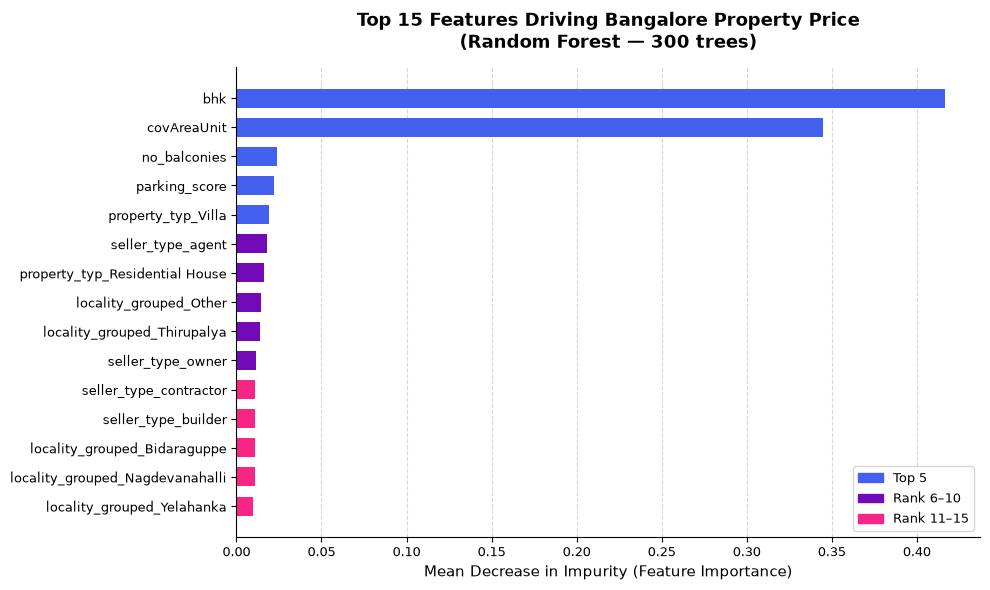

Chart saved → real_estate_outputs/feature_importance.png


In [33]:
# ==================================================
# FEATURE IMPORTANCE — What actually drives price?
# ==================================================

import matplotlib.patches as mpatches

# --------------------------------------------------
# Extract feature names from the fitted pipeline
# --------------------------------------------------

ohe = pipeline.named_steps["preprocessor"].named_transformers_["categorical"].named_steps["encoder"]
ohe_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(ohe_feature_names)

# --------------------------------------------------
# Get importances and pick top 15
# --------------------------------------------------

importances = pipeline.named_steps["model"].feature_importances_

feat_imp = (
    pd.DataFrame({
        "feature": all_feature_names,
        "importance": importances,
    })
    .sort_values("importance", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print(feat_imp.to_string(index=False))

# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

palette = ["#4361ee"] * 5 + ["#7209b7"] * 5 + ["#f72585"] * 5
colors = palette[: len(feat_imp)]

ax.barh(
    feat_imp["feature"][::-1],
    feat_imp["importance"][::-1],
    color=colors[::-1],
    edgecolor="none",
    height=0.65,
)

ax.set_xlabel("Mean Decrease in Impurity (Feature Importance)", fontsize=11)
ax.set_title(
    "Top 15 Features Driving Bangalore Property Price\n(Random Forest — 300 trees)",
    fontsize=13,
    fontweight="bold",
    pad=14,
)

ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=9)
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

top5_patch = mpatches.Patch(color="#4361ee", label="Top 5")
mid_patch = mpatches.Patch(color="#7209b7", label="Rank 6–10")
low_patch = mpatches.Patch(color="#f72585", label="Rank 11–15")
ax.legend(handles=[top5_patch, mid_patch, low_patch], loc="lower right", fontsize=9)

import os
os.makedirs("real_estate_outputs", exist_ok=True)
plt.tight_layout()
plt.savefig("real_estate_outputs/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → real_estate_outputs/feature_importance.png")


In [34]:
from sklearn.model_selection import GroupKFold, cross_val_predict

# --------------------------------------------------
# GROUPED OUT-OF-FOLD PREDICTIONS
# --------------------------------------------------

X_all = model_df[numeric_features + categorical_features]
y_all_log = np.log1p(model_df["actualprice"])

groups = model_df["listing_fingerprint"]

group_kf = GroupKFold(
    n_splits=5
)

oof_predictions_log = cross_val_predict(
    pipeline,
    X_all,
    y_all_log,
    cv=group_kf,
    groups=groups,
    n_jobs=1
)

# Convert predictions back to actual price
model_df["predicted_price"] = np.expm1(
    oof_predictions_log
)

# --------------------------------------------------
# PRICE DEVIATION
# --------------------------------------------------

model_df["price_deviation"] = (
    model_df["actualprice"]
    - model_df["predicted_price"]
)

model_df["deviation_pct"] = (
    model_df["price_deviation"]
    / model_df["predicted_price"]
) * 100

model_df["absolute_deviation_pct"] = (
    model_df["deviation_pct"].abs()
)

print("Grouped out-of-fold predictions created.")

print("\nDeviation summary:")
print(
    model_df["deviation_pct"].describe()
)

Grouped out-of-fold predictions created.

Deviation summary:
count   5,479.00
mean       14.20
std        73.26
min       -93.71
25%       -10.81
50%        -0.21
75%        28.15
max     1,722.61
Name: deviation_pct, dtype: float64


In [35]:
print("Predicted price summary:")
print(
    model_df["predicted_price"].describe()
)

print("\nDeviation percentage summary:")
print(
    model_df["deviation_pct"].describe(
        percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Predicted price summary:
count        5,479.00
mean    31,844,842.47
std     15,106,701.41
min      1,733,597.25
25%     18,927,968.93
50%     31,848,821.78
75%     39,015,269.80
max     89,851,866.84
Name: predicted_price, dtype: float64

Deviation percentage summary:
count   5,479.00
mean       14.20
std        73.26
min       -93.71
1%        -68.73
5%        -45.49
10%       -40.91
25%       -10.81
50%        -0.21
75%        28.15
90%        73.84
95%       108.75
99%       288.02
max     1,722.61
Name: deviation_pct, dtype: float64


In [36]:
# Inspect the most extreme deviations

model_df["absolute_deviation_pct"] = (
    model_df["deviation_pct"].abs()
)

extreme_deviations = (
    model_df[
        [
            "auto_des",
            "actualprice",
            "predicted_price",
            "price_deviation",
            "deviation_pct",
            "covAreaUnit",
            "bhk",
            "locality",
            "property_typ",
            "seller_type",
            "duplicate_flag"
        ]
    ]
    .sort_values(
        "deviation_pct",
        key=lambda x: x.abs(),
        ascending=False
    )
)

extreme_deviations.head(20)# Inspect the most extreme deviations

model_df["absolute_deviation_pct"] = (
    model_df["deviation_pct"].abs()
)

extreme_deviations = (
    model_df[
        [
            "auto_des",
            "actualprice",
            "predicted_price",
            "price_deviation",
            "deviation_pct",
            "covAreaUnit",
            "bhk",
            "locality",
            "property_typ",
            "seller_type",
            "duplicate_flag"
        ]
    ]
    .sort_values(
        "deviation_pct",
        key=lambda x: x.abs(),
        ascending=False
    )
)

extreme_deviations.head(20)

,auto_des,actualprice,predicted_price,price_deviation,deviation_pct,covAreaUnit,bhk,locality,property_typ,seller_type,duplicate_flag
2558,"7 BHK, Residential House is available for Sale...",400000000,"21,946,564.60","378,053,435.40","1,722.61","2,775.00",7.00,Talaghattapura,Villa,agent,False
1604,"1 BHK, Residential House is available for Sale...",46000000,"3,100,441.18","42,899,558.82","1,383.66","3,200.00",1.00,"Himagiri Meadows, Gottigere, bannerghatta main...",Villa,agent,False
1530,"10 BHK, Residential House is available for Sal...",420000000,"31,966,719.87","388,033,280.13","1,213.87","7,800.00",10.00,Dollars Colony Stage 2nd RMV,Residential House,builder,False
697,"3 BHK, Residential House is available for Sale...",195000000,"16,972,984.08","178,027,015.92","1,048.88","19,500.00",3.00,Panathur,Villa,owner,False
674,"8 BHK, Residential House is available for Sale...",280000000,"24,819,946.58","255,180,053.42","1,028.12","5,400.00",8.00,Chakravarthy Layout,Residential House,builder,False
1644,"4 BHK, Residential House is available for Sale...",225000000,"23,367,185.00","201,632,815.00",862.89,"2,000.00",4.00,Block 2nd Anjanapura,Residential House,contractor,False
417,"2 BHK, Residential House is available for Sale...",69600000,"7,345,129.29","62,254,870.71",847.57,"2,478.00",2.00,Bommasandra,Villa,builder,False
1490,"5 BHK, Residential House is available for Sale...",150000000,"17,758,749.30","132,241,250.70",744.65,"2,000.00",5.00,Devanahalli,Villa,owner,False
1869,"10 BHK, Residential House is available for Sal...",180000000,"22,181,763.25","157,818,236.75",711.48,"4,200.00",10.00,"D Costa Layout, Cooke Town",Residential House,contractor,False
134,"5 BHK, Residential House is available for Sale...",400000000,"50,135,830.99","349,864,169.01",697.83,"6,700.00",5.00,Defence Colony Indiranagar,Residential House,agent,False


In [37]:
thresholds = [25, 50, 75, 100, 150, 200]

for threshold in thresholds:
    count = (
        model_df["absolute_deviation_pct"] >= threshold
    ).sum()

    percentage = (
        count / len(model_df)
    ) * 100

    print(
        f"±{threshold}% : "
        f"{count:,} records "
        f"({percentage:.1f}%)"
    )

±25% : 2,529 records (46.2%)
±50% : 1,058 records (19.3%)
±75% : 575 records (10.5%)
±100% : 305 records (5.6%)
±150% : 153 records (2.8%)
±200% : 97 records (1.8%)


In [38]:
# --------------------------------------------------
# EXTREME AREA FLAG
# --------------------------------------------------

area_q1 = model_df["covAreaUnit"].quantile(0.25)
area_q3 = model_df["covAreaUnit"].quantile(0.75)

area_iqr = area_q3 - area_q1

area_upper_limit = area_q3 + (1.5 * area_iqr)

model_df["extreme_area_flag"] = (
    model_df["covAreaUnit"] > area_upper_limit
)

print("Area upper limit:", round(area_upper_limit, 2))

print(
    "\nExtreme-area records:",
    model_df["extreme_area_flag"].sum()
)

Area upper limit: 4050.0

Extreme-area records: 221


In [39]:
# --------------------------------------------------
# FINAL VALUATION REVIEW CLASSIFICATION
# --------------------------------------------------

model_df["valuation_review"] = "Normal"

# High-deviation cases
model_df.loc[
    model_df["deviation_pct"] >= 100,
    "valuation_review"
] = "Potentially Overpriced"

model_df.loc[
    model_df["deviation_pct"] <= -50,
    "valuation_review"
] = "Potentially Underpriced"

# Add a separate data-quality indicator
model_df["review_reason"] = "Within expected range"

model_df.loc[
    model_df["valuation_review"] == "Potentially Overpriced",
    "review_reason"
] = "Large positive price deviation"

model_df.loc[
    model_df["valuation_review"] == "Potentially Underpriced",
    "review_reason"
] = "Large negative price deviation"

# Add data-quality context
model_df.loc[
    model_df["extreme_area_flag"],
    "review_reason"
] = (
    model_df.loc[
        model_df["extreme_area_flag"],
        "review_reason"
    ]
    + " + Extreme area"
)

model_df.loc[
    model_df["duplicate_flag"],
    "review_reason"
] = (
    model_df.loc[
        model_df["duplicate_flag"],
        "review_reason"
    ]
    + " + Repeated listing pattern"
)

print(
    model_df["valuation_review"].value_counts()
)

valuation_review
Normal                     4952
Potentially Overpriced      305
Potentially Underpriced     222
Name: count, dtype: int64


In [40]:
# --------------------------------------------------
# FINAL AUDIT / REVIEW TABLE
# --------------------------------------------------

audit_columns = [
    "auto_des",
    "actualprice",
    "predicted_price",
    "price_deviation",
    "deviation_pct",
    "covAreaUnit",
    "bhk",
    "locality",
    "property_typ",
    "seller_type",
    "duplicate_flag",
    "extreme_area_flag",
    "valuation_review",
    "review_reason"
]

audit_table = (
    model_df[audit_columns]
    .sort_values(
        "deviation_pct",
        key=lambda x: x.abs(),
        ascending=False
    )
    .copy()
)

print("Audit table records:", len(audit_table))

audit_table.head(20)

Audit table records: 5479


,auto_des,actualprice,predicted_price,price_deviation,deviation_pct,covAreaUnit,bhk,locality,property_typ,seller_type,duplicate_flag,extreme_area_flag,valuation_review,review_reason
2558,"7 BHK, Residential House is available for Sale...",400000000,"21,946,564.60","378,053,435.40","1,722.61","2,775.00",7.00,Talaghattapura,Villa,agent,False,False,Potentially Overpriced,Large positive price deviation
1604,"1 BHK, Residential House is available for Sale...",46000000,"3,100,441.18","42,899,558.82","1,383.66","3,200.00",1.00,"Himagiri Meadows, Gottigere, bannerghatta main...",Villa,agent,False,False,Potentially Overpriced,Large positive price deviation
1530,"10 BHK, Residential House is available for Sal...",420000000,"31,966,719.87","388,033,280.13","1,213.87","7,800.00",10.00,Dollars Colony Stage 2nd RMV,Residential House,builder,False,True,Potentially Overpriced,Large positive price deviation + Extreme area
697,"3 BHK, Residential House is available for Sale...",195000000,"16,972,984.08","178,027,015.92","1,048.88","19,500.00",3.00,Panathur,Villa,owner,False,True,Potentially Overpriced,Large positive price deviation + Extreme area
674,"8 BHK, Residential House is available for Sale...",280000000,"24,819,946.58","255,180,053.42","1,028.12","5,400.00",8.00,Chakravarthy Layout,Residential House,builder,False,True,Potentially Overpriced,Large positive price deviation + Extreme area
1644,"4 BHK, Residential House is available for Sale...",225000000,"23,367,185.00","201,632,815.00",862.89,"2,000.00",4.00,Block 2nd Anjanapura,Residential House,contractor,False,False,Potentially Overpriced,Large positive price deviation
417,"2 BHK, Residential House is available for Sale...",69600000,"7,345,129.29","62,254,870.71",847.57,"2,478.00",2.00,Bommasandra,Villa,builder,False,False,Potentially Overpriced,Large positive price deviation
1490,"5 BHK, Residential House is available for Sale...",150000000,"17,758,749.30","132,241,250.70",744.65,"2,000.00",5.00,Devanahalli,Villa,owner,False,False,Potentially Overpriced,Large positive price deviation
1869,"10 BHK, Residential House is available for Sal...",180000000,"22,181,763.25","157,818,236.75",711.48,"4,200.00",10.00,"D Costa Layout, Cooke Town",Residential House,contractor,False,True,Potentially Overpriced,Large positive price deviation + Extreme area
134,"5 BHK, Residential House is available for Sale...",400000000,"50,135,830.99","349,864,169.01",697.83,"6,700.00",5.00,Defence Colony Indiranagar,Residential House,agent,False,True,Potentially Overpriced,Large positive price deviation + Extreme area


In [41]:
# --------------------------------------------------
# FINAL REVIEW CATEGORIES
# --------------------------------------------------

model_df["review_category"] = "Normal"

# Strong valuation deviations
model_df.loc[
    model_df["deviation_pct"] >= 100,
    "review_category"
] = "Potentially Overpriced"

model_df.loc[
    model_df["deviation_pct"] <= -50,
    "review_category"
] = "Potentially Underpriced"

# Data-quality context
model_df["data_quality_indicator"] = "None"

model_df.loc[
    model_df["extreme_area_flag"],
    "data_quality_indicator"
] = "Extreme Area"

model_df.loc[
    model_df["duplicate_flag"],
    "data_quality_indicator"
] = "Repeated Listing"

# Both indicators
model_df.loc[
    model_df["extreme_area_flag"] &
    model_df["duplicate_flag"],
    "data_quality_indicator"
] = "Extreme Area + Repeated Listing"

print("Review category:")
print(model_df["review_category"].value_counts())

print("\nData-quality indicators:")
print(model_df["data_quality_indicator"].value_counts())

Review category:
review_category
Normal                     4952
Potentially Overpriced      305
Potentially Underpriced     222
Name: count, dtype: int64

Data-quality indicators:
data_quality_indicator
Repeated Listing    3920
None                1338
Extreme Area         221
Name: count, dtype: int64


In [42]:
# --------------------------------------------------
# VALUATION ANOMALIES WITH DATA-QUALITY CONTEXT
# --------------------------------------------------

review_candidates = (
    model_df[
        model_df["review_category"] != "Normal"
    ][
        [
            "auto_des",
            "actualprice",
            "predicted_price",
            "price_deviation",
            "deviation_pct",
            "covAreaUnit",
            "bhk",
            "locality",
            "property_typ",
            "seller_type",
            "duplicate_flag",
            "extreme_area_flag",
            "review_category",
            "data_quality_indicator"
        ]
    ]
    .sort_values(
        "deviation_pct",
        key=lambda x: x.abs(),
        ascending=False
    )
)

print(
    "Review candidates:",
    len(review_candidates)
)

review_candidates.head(20)

Review candidates: 527


,auto_des,actualprice,predicted_price,price_deviation,deviation_pct,covAreaUnit,bhk,locality,property_typ,seller_type,duplicate_flag,extreme_area_flag,review_category,data_quality_indicator
2558,"7 BHK, Residential House is available for Sale...",400000000,"21,946,564.60","378,053,435.40","1,722.61","2,775.00",7.00,Talaghattapura,Villa,agent,False,False,Potentially Overpriced,None
1604,"1 BHK, Residential House is available for Sale...",46000000,"3,100,441.18","42,899,558.82","1,383.66","3,200.00",1.00,"Himagiri Meadows, Gottigere, bannerghatta main...",Villa,agent,False,False,Potentially Overpriced,None
1530,"10 BHK, Residential House is available for Sal...",420000000,"31,966,719.87","388,033,280.13","1,213.87","7,800.00",10.00,Dollars Colony Stage 2nd RMV,Residential House,builder,False,True,Potentially Overpriced,Extreme Area
697,"3 BHK, Residential House is available for Sale...",195000000,"16,972,984.08","178,027,015.92","1,048.88","19,500.00",3.00,Panathur,Villa,owner,False,True,Potentially Overpriced,Extreme Area
674,"8 BHK, Residential House is available for Sale...",280000000,"24,819,946.58","255,180,053.42","1,028.12","5,400.00",8.00,Chakravarthy Layout,Residential House,builder,False,True,Potentially Overpriced,Extreme Area
1644,"4 BHK, Residential House is available for Sale...",225000000,"23,367,185.00","201,632,815.00",862.89,"2,000.00",4.00,Block 2nd Anjanapura,Residential House,contractor,False,False,Potentially Overpriced,None
417,"2 BHK, Residential House is available for Sale...",69600000,"7,345,129.29","62,254,870.71",847.57,"2,478.00",2.00,Bommasandra,Villa,builder,False,False,Potentially Overpriced,None
1490,"5 BHK, Residential House is available for Sale...",150000000,"17,758,749.30","132,241,250.70",744.65,"2,000.00",5.00,Devanahalli,Villa,owner,False,False,Potentially Overpriced,None
1869,"10 BHK, Residential House is available for Sal...",180000000,"22,181,763.25","157,818,236.75",711.48,"4,200.00",10.00,"D Costa Layout, Cooke Town",Residential House,contractor,False,True,Potentially Overpriced,Extreme Area
134,"5 BHK, Residential House is available for Sale...",400000000,"50,135,830.99","349,864,169.01",697.83,"6,700.00",5.00,Defence Colony Indiranagar,Residential House,agent,False,True,Potentially Overpriced,Extreme Area


In [43]:
# --------------------------------------------------
# REVIEW CANDIDATE DATA-QUALITY OVERLAP
# --------------------------------------------------

review_only = model_df[
    model_df["review_category"] != "Normal"
].copy()

print("Total review candidates:", len(review_only))

print("\nRepeated listings among review candidates:")
print(
    review_only["duplicate_flag"].value_counts()
)

print("\nExtreme-area records among review candidates:")
print(
    review_only["extreme_area_flag"].value_counts()
)

print("\nBoth indicators among review candidates:")
print(
    (
        review_only["duplicate_flag"] &
        review_only["extreme_area_flag"]
    ).sum()
)

Total review candidates: 527

Repeated listings among review candidates:
duplicate_flag
False    456
True      71
Name: count, dtype: int64

Extreme-area records among review candidates:
extreme_area_flag
False    446
True      81
Name: count, dtype: int64

Both indicators among review candidates:
0


In [44]:
# --------------------------------------------------
# LOCALITY-LEVEL VALUATION ANALYSIS
# --------------------------------------------------

locality_analysis = (
    model_df
    .groupby("locality_grouped", dropna=False)
    .agg(
        listings=("actualprice", "count"),
        median_price=("actualprice", "median"),
        median_predicted_price=("predicted_price", "median"),
        median_deviation_pct=("deviation_pct", "median"),
        anomaly_count=(
            "review_category",
            lambda x: (x != "Normal").sum()
        ),
        overpriced_count=(
            "review_category",
            lambda x: (x == "Potentially Overpriced").sum()
        ),
        underpriced_count=(
            "review_category",
            lambda x: (x == "Potentially Underpriced").sum()
        )
    )
    .reset_index()
)

locality_analysis["anomaly_rate_pct"] = (
    locality_analysis["anomaly_count"]
    / locality_analysis["listings"]
) * 100

locality_analysis = locality_analysis.sort_values(
    "anomaly_count",
    ascending=False
)

locality_analysis.head(20)

,locality_grouped,listings,median_price,median_predicted_price,median_deviation_pct,anomaly_count,overpriced_count,underpriced_count,anomaly_rate_pct
13,Other,930,"19,850,000.00","21,234,657.03",-2.66,254,129,125,27.31
15,Sarjapur Road,801,"37,500,000.00","37,606,391.66",-7.14,90,80,10,11.24
19,Whitefield,103,"28,500,000.00","28,505,802.30",7.01,40,22,18,38.83
14,Phase 2 Electronic City,49,"16,000,000.00","14,430,320.67",-0.82,17,11,6,34.69
7,Devanahalli,791,"50,000,000.00","39,015,269.80",0.29,15,8,7,1.90
12,Nagdevanahalli,27,"6,650,000.00","8,092,085.48",-18.58,13,4,9,48.15
11,Krishnarajapura,32,"20,000,000.00","20,553,848.20",-1.83,12,9,3,37.50
4,Block 2nd Anjanapura,28,"25,500,000.00","21,202,069.57",3.85,11,4,7,39.29
20,Yelahanka,536,"32,500,000.00","55,000,000.00",-1.25,10,7,3,1.87
10,Kothnur Narayanapura,24,"20,000,000.00","19,072,489.63",17.70,9,6,3,37.50


In [45]:
# Localities with at least 20 modeled listings

locality_priority = (
    locality_analysis[
        locality_analysis["listings"] >= 20
    ]
    .sort_values(
        "anomaly_rate_pct",
        ascending=False
    )
)

locality_priority.head(15)

,locality_grouped,listings,median_price,median_predicted_price,median_deviation_pct,anomaly_count,overpriced_count,underpriced_count,anomaly_rate_pct
12,Nagdevanahalli,27,"6,650,000.00","8,092,085.48",-18.58,13,4,9,48.15
1,Anjanapura Township,21,"17,500,000.00","24,282,125.56",-13.54,9,4,5,42.86
4,Block 2nd Anjanapura,28,"25,500,000.00","21,202,069.57",3.85,11,4,7,39.29
19,Whitefield,103,"28,500,000.00","28,505,802.30",7.01,40,22,18,38.83
5,Block 3rd HRBR Layout,21,"15,200,000.00","18,535,293.67",-11.14,8,3,5,38.10
10,Kothnur Narayanapura,24,"20,000,000.00","19,072,489.63",17.70,9,6,3,37.50
11,Krishnarajapura,32,"20,000,000.00","20,553,848.20",-1.83,12,9,3,37.50
2,Bannerghatta Main Road,25,"28,000,000.00","26,235,259.40",6.19,9,6,3,36.00
14,Phase 2 Electronic City,49,"16,000,000.00","14,430,320.67",-0.82,17,11,6,34.69
9,"Himagiri Meadows, Gottigere, bannerghatta main...",24,"19,950,000.00","22,079,195.95",-2.48,8,4,4,33.33


In [46]:
# --------------------------------------------------
# PROPERTY TYPE ANALYSIS
# --------------------------------------------------

property_analysis = (
    model_df
    .groupby("property_typ", dropna=False)
    .agg(
        listings=("actualprice", "count"),
        median_price=("actualprice", "median"),
        median_deviation_pct=("deviation_pct", "median"),
        anomaly_count=(
            "review_category",
            lambda x: (x != "Normal").sum()
        ),
        overpriced_count=(
            "review_category",
            lambda x: (x == "Potentially Overpriced").sum()
        ),
        underpriced_count=(
            "review_category",
            lambda x: (x == "Potentially Underpriced").sum()
        )
    )
    .reset_index()
)

property_analysis["anomaly_rate_pct"] = (
    property_analysis["anomaly_count"]
    / property_analysis["listings"]
) * 100

property_analysis.sort_values(
    "anomaly_rate_pct",
    ascending=False
)

,property_typ,listings,median_price,median_deviation_pct,anomaly_count,overpriced_count,underpriced_count,anomaly_rate_pct
1,Unknown,38,"15,000,000.00",-9.52,15,7,8,39.47
0,Residential House,859,"18,000,000.00",-0.67,253,129,124,29.45
2,Villa,4582,"32,000,000.00",-0.21,259,169,90,5.65


In [47]:
# --------------------------------------------------
# FINAL MODEL PERFORMANCE
# --------------------------------------------------

from sklearn.metrics import mean_absolute_error, r2_score

grouped_mae = mean_absolute_error(
    model_df["actualprice"],
    model_df["predicted_price"]
)

grouped_r2 = r2_score(
    model_df["actualprice"],
    model_df["predicted_price"]
)

print("Final Grouped 5-Fold OOF Performance")
print("------------------------------------")
print("R² :", round(grouped_r2, 4))
print("MAE:", round(grouped_mae, 2))

Final Grouped 5-Fold OOF Performance
------------------------------------
R² : 0.2797
MAE: 9458712.44


In [48]:
# ============================================================
# FINAL PROJECT OUTPUTS
# ============================================================

import os

output_dir = "real_estate_outputs"
os.makedirs(output_dir, exist_ok=True)

print("Output directory ready:", output_dir)

Output directory ready: real_estate_outputs


In [49]:
# ============================================================
# 2. FLAGGED PRICE ANOMALIES
# ============================================================

flagged_price_anomalies = model_df[
    model_df["review_category"] != "Normal"
].copy()

flagged_price_anomalies.to_csv(
    os.path.join(
        output_dir,
        "flagged_price_anomalies.csv"
    ),
    index=False
)

print(
    "Flagged records:",
    len(flagged_price_anomalies)
)

print(
    flagged_price_anomalies[
        "review_category"
    ].value_counts()
)

Flagged records:

 527
review_category
Potentially Overpriced     305
Potentially Underpriced    222
Name: count, dtype: int64


In [50]:
# ============================================================
# 3. LOCALITY ANALYSIS
# ============================================================

locality_analysis.to_csv(
    os.path.join(
        output_dir,
        "locality_analysis.csv"
    ),
    index=False
)

print(
    "Locality analysis saved:",
    len(locality_analysis),
    "locality groups"
)

Locality analysis saved: 21 locality groups


In [51]:
# ============================================================
# 4. PROPERTY TYPE ANALYSIS
# ============================================================

property_analysis.to_csv(
    os.path.join(
        output_dir,
        "property_type_analysis.csv"
    ),
    index=False
)

print(
    "Property analysis saved."
)

Property analysis saved.


In [52]:
# ============================================================
# 5. POWER BI DATASET
# ============================================================

powerbi_columns = [
    "actualprice",
    "predicted_price",
    "price_deviation",
    "deviation_pct",
    "absolute_deviation_pct",
    "covAreaUnit",
    "bhk",
    "no_balconies",
    "parking_score",
    "locality_grouped",
    "property_typ",
    "psnstats",
    "seller_type",
    "duplicate_flag",
    "extreme_area_flag",
    "review_category",
    "data_quality_indicator"
]

powerbi_data = model_df[
    powerbi_columns
].copy()

powerbi_data.to_csv(
    os.path.join(
        output_dir,
        "powerbi_real_estate_data.csv"
    ),
    index=False
)

print(
    "Power BI dataset created."
)

print(
    "Rows:",
    len(powerbi_data)
)

print(
    "Columns:",
    len(powerbi_data.columns)
)

Power BI dataset created.
Rows: 5479
Columns: 17


In [53]:
# ============================================================
# 6. PROJECT SUMMARY
# ============================================================

summary = pd.DataFrame({
    "metric": [
        "Raw records",
        "Modeling records",
        "Potentially overpriced",
        "Potentially underpriced",
        "Total review candidates",
        "Extreme-area records",
        "Repeated-listing records",
        "Model R2",
        "Model MAE"
    ],
    "value": [
        len(df),
        len(model_df),
        (model_df["review_category"] == "Potentially Overpriced").sum(),
        (model_df["review_category"] == "Potentially Underpriced").sum(),
        (model_df["review_category"] != "Normal").sum(),
        model_df["extreme_area_flag"].sum(),
        model_df["duplicate_flag"].sum(),
        grouped_r2,
        grouped_mae
    ]
})

summary.to_csv(
    os.path.join(
        output_dir,
        "project_summary.csv"
    ),
    index=False
)

summary

,metric,value
0,Raw records,"10,320.00"
1,Modeling records,"5,479.00"
2,Potentially overpriced,305.00
3,Potentially underpriced,222.00
4,Total review candidates,527.00
5,Extreme-area records,221.00
6,Repeated-listing records,"3,920.00"
7,Model R2,0.28
8,Model MAE,"9,458,712.44"


In [54]:
# --------------------------------------------------
# ANOMALY FLAGS
# --------------------------------------------------

model_df["anomaly_type"] = "Normal"

model_df.loc[
    model_df["deviation_pct"] >= 25,
    "anomaly_type"
] = "Potentially Overpriced"

model_df.loc[
    model_df["deviation_pct"] <= -25,
    "anomaly_type"
] = "Potentially Underpriced"

model_df["is_price_anomaly"] = (
    model_df["anomaly_type"] != "Normal"
)

print(
    model_df["anomaly_type"]
    .value_counts()
)

anomaly_type
Normal                     2950
Potentially Overpriced     1511
Potentially Underpriced    1018
Name: count, dtype: int64